# HOUSE KEEPING

In [ ]:
import sys
import os
sys.path.append('/scratch_net/ken/radjoe/Projects/Experiments/SAMEXP/')

import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats 
from scipy.stats import shapiro , kstest, mannwhitneyu, ttest_rel, wilcoxon
import torch
from torch import nn
from datasets.datasets import MRIDataset, STAREDataset

from helper_func.analyis_helper import clean_df, plot_boxplots, visualize, generate_batch_views, visualize_views, visualize_class_centroids, visualize_feats, prod_feats
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

## Load modalities

In [34]:
na_ssa = '/scratch/radjoe/Projects/Experiments/SAMEXP/results/TT_NA_SSA/boxes/SSA_boxes.csv'
a_ssa = '/scratch/radjoe/Projects/Experiments/SAMEXP/results/TT_A_SSA/boxes/SSA_boxes.csv'

In [35]:
na_ssa_df = pd.read_csv(na_ssa)
na_ssa_df = clean_df(na_ssa_df, True, 'brats')
a_ssa_df = pd.read_csv(a_ssa)
a_ssa_df = clean_df(a_ssa_df, True, 'brats')

In [36]:
na_ssa_df

,name,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET,recall_NCR,recall_ED,recall_ET,precision_NCR,precision_ED,precision_ET
0,BraTS-SSA-00002-000.npy,0.405957,0.881102,0.728119,37.357056,12.884099,72.365730,0.899894,0.893997,0.639472,0.262097,0.868574,0.845299
1,BraTS-SSA-00012-000.npy,0.860987,0.873251,0.703306,3.605551,48.228622,62.091831,0.994836,0.975560,0.753016,0.758884,0.790365,0.659753
2,BraTS-SSA-00049-000.npy,0.872074,0.769765,0.850662,2.236068,42.673176,58.083569,0.860781,0.952165,0.898448,0.883666,0.646013,0.807703
3,BraTS-SSA-00096-000.npy,0.812003,0.578594,0.654730,10.246951,15.308474,13.003844,0.772676,0.465267,0.541164,0.855547,0.764903,0.828622
4,BraTS-SSA-00113-000.npy,0.883940,0.792710,0.644667,4.577075,22.293497,16.278820,0.827667,0.781040,0.803804,0.948424,0.804735,0.538129
5,BraTS-SSA-00115-000.npy,0.628451,0.277822,0.466160,6.082763,46.043457,41.484936,0.603681,0.698824,0.358492,0.655341,0.173374,0.666261
6,BraTS-SSA-00119-000.npy,0.332665,0.636030,0.675059,45.822964,64.292679,48.533493,0.384259,0.599577,0.663842,0.293286,0.677202,0.686662
7,BraTS-SSA-00152-000.npy,0.769118,0.725482,0.885938,5.385165,43.692104,8.602325,0.698904,0.821422,0.880933,0.855014,0.649610,0.891000
8,BraTS-SSA-00223-000.npy,0.187597,0.884516,0.717911,8.544003,12.727922,5.830952,0.108287,0.967102,0.584101,0.701043,0.814925,0.931247


In [37]:
a_ssa_df

,name,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET,recall_NCR,recall_ED,recall_ET,precision_NCR,precision_ED,precision_ET
0,BraTS-SSA-00002-000.npy,0.559861,0.901478,0.656419,8.544003,21.954498,5.744563,0.978040,0.870486,0.515843,0.392178,0.934758,0.902316
1,BraTS-SSA-00012-000.npy,0.836975,0.856495,0.718330,5.196152,43.665207,39.971199,0.991178,0.857724,0.581433,0.724292,0.855270,0.939541
2,BraTS-SSA-00049-000.npy,0.850239,0.802588,0.846821,2.828427,48.769348,58.403767,0.787952,0.842691,0.827064,0.923219,0.766128,0.867544
3,BraTS-SSA-00096-000.npy,0.733146,0.345016,0.742987,20.571823,41.243183,10.630146,0.730546,0.243778,0.726868,0.735765,0.590061,0.759838
4,BraTS-SSA-00113-000.npy,0.754802,0.776796,0.611024,47.520000,50.575169,16.982157,0.767884,0.783401,0.491701,0.742158,0.770302,0.806818
5,BraTS-SSA-00115-000.npy,0.616795,0.293922,0.465482,8.246211,44.944408,17.501390,0.739748,0.477532,0.335355,0.528889,0.212295,0.760629
6,BraTS-SSA-00119-000.npy,0.320641,0.566169,0.543444,8.306623,39.458839,44.269630,0.370370,0.506927,0.432868,0.282686,0.641089,0.729896
7,BraTS-SSA-00152-000.npy,0.814407,0.734292,0.859619,3.162278,29.427877,5.477226,0.879401,0.741690,0.792703,0.758359,0.727041,0.938874
8,BraTS-SSA-00223-000.npy,0.206508,0.877770,0.668171,34.856842,31.968735,8.062258,0.127797,0.906144,0.526743,0.537651,0.851120,0.913422


## Better on AUG

In [38]:
a_ssa_df['dice_ED'] > na_ssa_df['dice_ED'] + 0.05

0    False
1    False
2    False
3    False
4    False
5    False
6    False
7    False
8    False
Name: dice_ED, dtype: bool

In [39]:
a_ssa_df[a_ssa_df['dice_ET'] > na_ssa_df['dice_ET'] + 0.05]

,name,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET,recall_NCR,recall_ED,recall_ET,precision_NCR,precision_ED,precision_ET
3,BraTS-SSA-00096-000.npy,0.733146,0.345016,0.742987,20.571823,41.243183,10.630146,0.730546,0.243778,0.726868,0.735765,0.590061,0.759838


In [40]:
na_ssa_df[a_ssa_df['dice_ET'] > na_ssa_df['dice_ET'] + 0.05]

,name,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET,recall_NCR,recall_ED,recall_ET,precision_NCR,precision_ED,precision_ET
3,BraTS-SSA-00096-000.npy,0.812003,0.578594,0.65473,10.246951,15.308474,13.003844,0.772676,0.465267,0.541164,0.855547,0.764903,0.828622


In [41]:
a_ssa_df[a_ssa_df['dice_NCR'] > na_ssa_df['dice_NCR'] + 0.05]

,name,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET,recall_NCR,recall_ED,recall_ET,precision_NCR,precision_ED,precision_ET
0,BraTS-SSA-00002-000.npy,0.559861,0.901478,0.656419,8.544003,21.954498,5.744563,0.97804,0.870486,0.515843,0.392178,0.934758,0.902316


In [42]:
na_ssa_df[a_ssa_df['dice_NCR'] > na_ssa_df['dice_NCR'] + 0.05]

,name,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET,recall_NCR,recall_ED,recall_ET,precision_NCR,precision_ED,precision_ET
0,BraTS-SSA-00002-000.npy,0.405957,0.881102,0.728119,37.357056,12.884099,72.36573,0.899894,0.893997,0.639472,0.262097,0.868574,0.845299


## Visualize Differences

In [43]:
def display_image(color, label, b1, frames, class_id, ax):
    colored_out_mask = np.zeros((label.shape[1],label.shape[2] , 3))
    colored_out_mask[label[class_id,:,:,frames] == 1] = color
    ax.imshow(colored_out_mask)
    ax.add_patch(plt.Rectangle(b1[0], b1[2] , -b1[1], ls="--", ec="c", fc="none"))
    

    
def renormalize(arr):
    foreground = arr[arr != 0]
    min_val, max_val = np.min(foreground), np.max(foreground)

    scaled = (arr - min_val) / (max_val - min_val + 1e-8)
    scaled[arr == 0] = 0 

    return scaled

def vis_image(path):
    image_path = path
    imgs = np.load(image_path)
    # imgs = np.delete(imgs, 1, axis=0)
    for i in range(imgs.shape[0]):
        imgs[i] = renormalize(imgs[i])
    imgs = np.transpose(imgs, (3, 1, 2,0))
    return imgs


def display_image(color, label, b1, frames, class_id, ax, title):
    
    # print(f'here {label.shape}')
    colored_out_mask = np.zeros((label.shape[1],label.shape[2], 3 ))
    mask = label[class_id, :, :, frames] == 1
    colored_out_mask[mask] = np.array(color, dtype=np.uint8)
    ax.imshow(colored_out_mask)
    # ax.add_patch(plt.Rectangle(b1[0], b1[2] , -b1[1], ls="--", ec="c", fc="none"))
    ax.set_title(title)
def preprocess_bbox(bbox):
    print(bbox)
    x = int(bbox[0][0]) 
    y = int(bbox[0][3]) 
    w = int(bbox[0][2]) - int(bbox[0][0])
    h = int(bbox[0][3]) - int(bbox[0][1])
    return (x,y) , h, w

def fig2img(fig):
    canvas = FigureCanvas(fig)  # Attach the Agg backend
    fig.set_canvas(canvas)      # Set the canvas to the figure
    canvas.draw()
    
    # Get the RGB buffer from the figure
    buf = canvas.buffer_rgba()  # Use buffer_rgba() instead of tostring_rgb
    img = np.asarray(buf)[:, :, :3]  # Drop alpha channel
    return img

def visualize(dataset, pred_path, title, path_img, pred_path2 = None ):
    colors = [
        [255, 0, 0],       
        [255, 255, 0],     
        [128, 0, 128],     
    ]
    # graph_num = len(pred_path)
    for i in range(len(dataset)):
        
        fig, ax = plt.subplots(3, 3)
        fig.subplots_adjust(hspace=0.3, wspace=0.3)

        # fig2, ax2 = plt.subplots(1, 3)
        # fig2.subplots_adjust(hspace=0.3, wspace=0.3)

        fig.suptitle(title)
        # print(len(ax))
        idx, img, label_name, box, points, frames, label = dataset[i]
        print(img)
        b1 = preprocess_bbox(bbox=box[0])
        # b2 = preprocess_bbox(bbox=box[1])
        # b3 = preprocess_bbox(bbox=box[2])
        b = [b1,b1, b1]
        
        read_path = os.path.join(pred_path, f'{img[:-8]}.npy')
        # print(read_path)
        pred = np.load(read_path)[1:]

   
        # pred = np.transpose(pred, (3,0,1,2))
        label = np.array(label[1:])
        print(f'label.shape {label.shape}, {frames}')
        # label = np.transpose(label, (1,2,3,0))


        if pred_path2:
            read_path2 = os.path.join(pred_path2, f'{img[:-8]}.npy')
            # loadpath2 = os.path.join(read_path2, os.listdir(read_path2)[0])
            pred2 = np.load(read_path2)[1:]
            # pred = np.load(read_path)[1:]
            # pred2 = np.transpose(pred2, (3,0,1,2))
        
        label_key = ['NCR','ED','ET']

        for i in range(3):
            display_image(colors[i], label, b[i],frames, i, ax[i,0], label_key[i])
            display_image(colors[i], pred, b[i], frames, i, ax[i,1], label_key[i])
            if pred_path2:
                display_image(colors[i], pred2, b[i], frames, i, ax[i,2],label_key[i] )

        true_img_path = f'{path_img}/{img}'
        true_img = vis_image(true_img_path)
        plt.show()
        for i in range(4):
            print(f'true_img shape: {true_img[frames, :,:, i].shape}')
            plt.imshow(true_img[frames, :,:, i], cmap='gray')
            plt.show()

In [44]:
na_ssa_df

,name,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET,recall_NCR,recall_ED,recall_ET,precision_NCR,precision_ED,precision_ET
0,BraTS-SSA-00002-000.npy,0.405957,0.881102,0.728119,37.357056,12.884099,72.365730,0.899894,0.893997,0.639472,0.262097,0.868574,0.845299
1,BraTS-SSA-00012-000.npy,0.860987,0.873251,0.703306,3.605551,48.228622,62.091831,0.994836,0.975560,0.753016,0.758884,0.790365,0.659753
2,BraTS-SSA-00049-000.npy,0.872074,0.769765,0.850662,2.236068,42.673176,58.083569,0.860781,0.952165,0.898448,0.883666,0.646013,0.807703
3,BraTS-SSA-00096-000.npy,0.812003,0.578594,0.654730,10.246951,15.308474,13.003844,0.772676,0.465267,0.541164,0.855547,0.764903,0.828622
4,BraTS-SSA-00113-000.npy,0.883940,0.792710,0.644667,4.577075,22.293497,16.278820,0.827667,0.781040,0.803804,0.948424,0.804735,0.538129
5,BraTS-SSA-00115-000.npy,0.628451,0.277822,0.466160,6.082763,46.043457,41.484936,0.603681,0.698824,0.358492,0.655341,0.173374,0.666261
6,BraTS-SSA-00119-000.npy,0.332665,0.636030,0.675059,45.822964,64.292679,48.533493,0.384259,0.599577,0.663842,0.293286,0.677202,0.686662
7,BraTS-SSA-00152-000.npy,0.769118,0.725482,0.885938,5.385165,43.692104,8.602325,0.698904,0.821422,0.880933,0.855014,0.649610,0.891000
8,BraTS-SSA-00223-000.npy,0.187597,0.884516,0.717911,8.544003,12.727922,5.830952,0.108287,0.967102,0.584101,0.701043,0.814925,0.931247


In [45]:
max_id = na_ssa_df[['dice_NCR', 'dice_ED', 'dice_ET']].idxmax(1)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB dat

BraTS-SSA-00002-000-stk.npy
[[ 94. 116. 101. 125.]]
label.shape (3, 192, 224, 160), 112


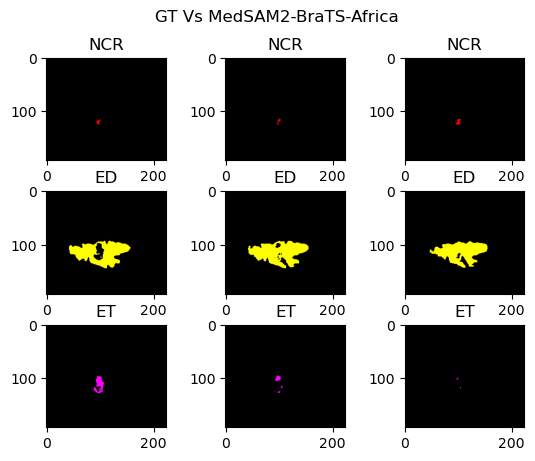

true_img shape: (192, 224)


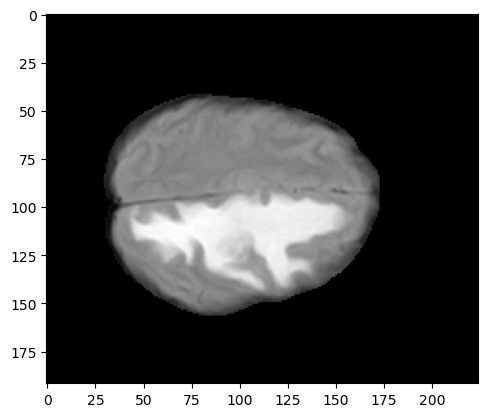

true_img shape: (192, 224)


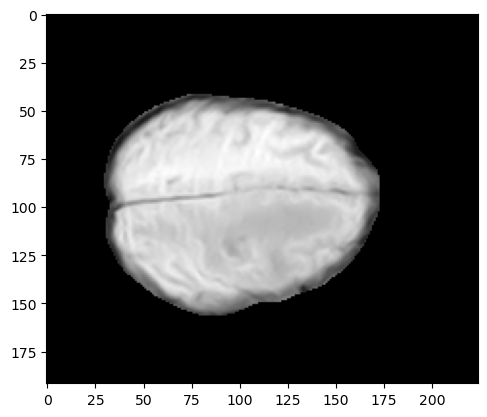

true_img shape: (192, 224)


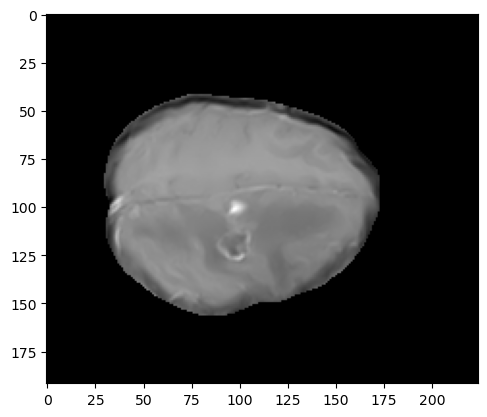

true_img shape: (192, 224)


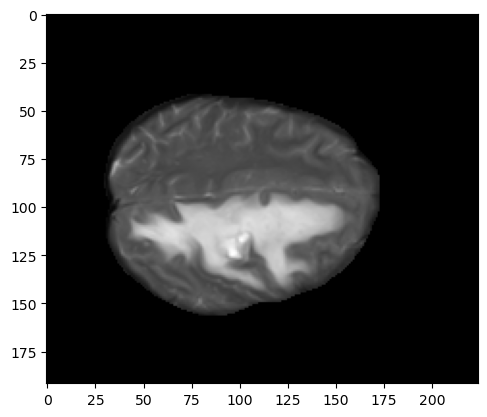

BraTS-SSA-00096-000-stk.npy
[[ 77.  39. 130. 110.]]
label.shape (3, 192, 224, 160), 65


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB dat

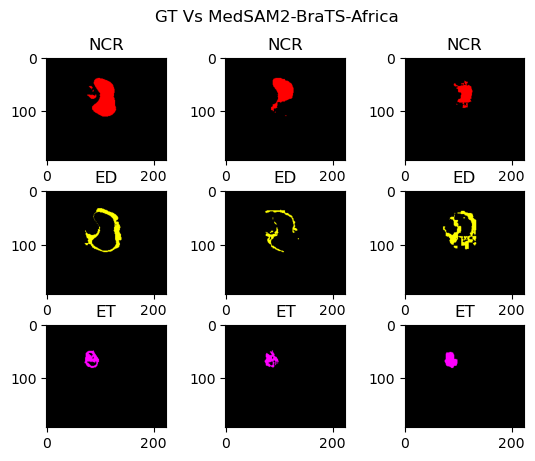

true_img shape: (192, 224)


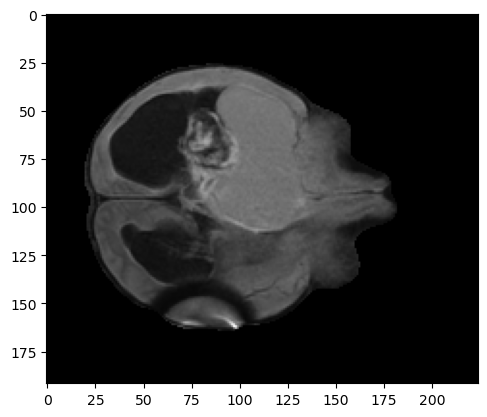

true_img shape: (192, 224)


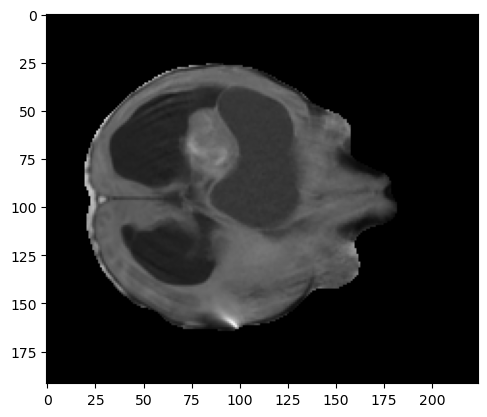

true_img shape: (192, 224)


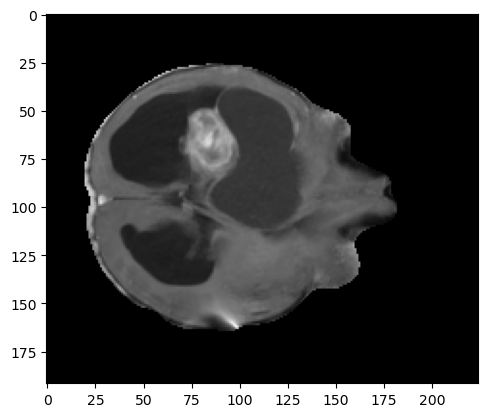

true_img shape: (192, 224)


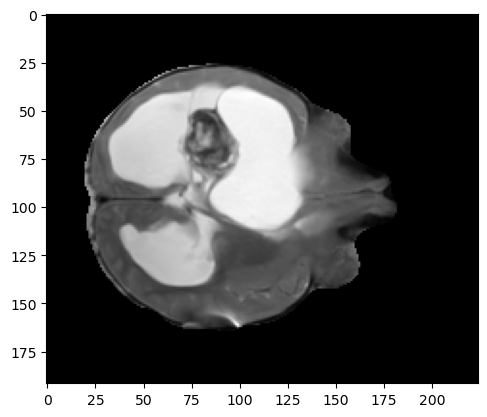

In [46]:
GLI_best_list = ['BraTS-SSA-00002-000.npy', 'BraTS-SSA-00096-000.npy']
GLI_video_path = "/scratch_net/ken/radjoe/BraTS_SSA/Test/images_UNN"
GLI_label_path  = "/scratch_net/ken/radjoe/BraTS_SSA/Test/labels_UNN"
GLI_best_dataset = MRIDataset(GLI_video_path, GLI_label_path, GLI_best_list)
pred1 = '/scratch/radjoe/Projects/Experiments/SAMEXP/results/TT_NA_SSA/boxes/'
pred2 = '/scratch/radjoe/Projects/Experiments/SAMEXP/logs/tta_feature_ent_no_eted_no_rad_no_focal_eq/logs/BraTS_GLI'
visualize(GLI_best_dataset,pred1,'GT Vs MedSAM2-BraTS-Africa', GLI_video_path, pred2)

In 2, ED is more diffuse, and NCR is bright
In 96, Better in ET, ED is super diffuse, ET has low brightness

## ED

In [21]:
na_ssa_df[max_id == 'dice_ED']

,name,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET,recall_NCR,recall_ED,recall_ET,precision_NCR,precision_ED,precision_ET
0,BraTS-SSA-00002-000.npy,0.405957,0.881102,0.728119,37.357056,12.884099,72.365730,0.899894,0.893997,0.639472,0.262097,0.868574,0.845299
1,BraTS-SSA-00012-000.npy,0.860987,0.873251,0.703306,3.605551,48.228622,62.091831,0.994836,0.975560,0.753016,0.758884,0.790365,0.659753
8,BraTS-SSA-00223-000.npy,0.187597,0.884516,0.717911,8.544003,12.727922,5.830952,0.108287,0.967102,0.584101,0.701043,0.814925,0.931247


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB dat

BraTS-SSA-00002-000-stk.npy
[[ 94. 116. 101. 125.]]
label.shape (3, 192, 224, 160), 112


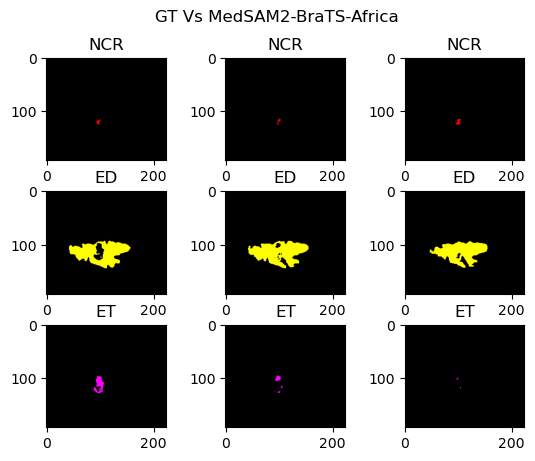

true_img shape: (192, 224)


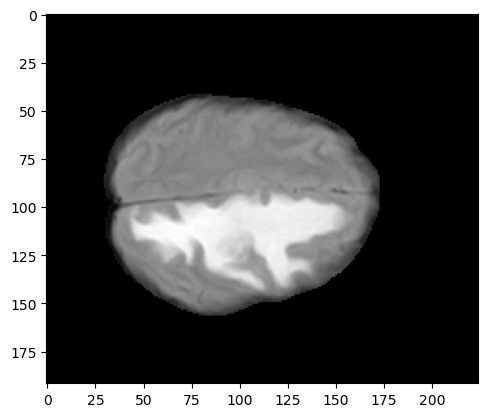

true_img shape: (192, 224)


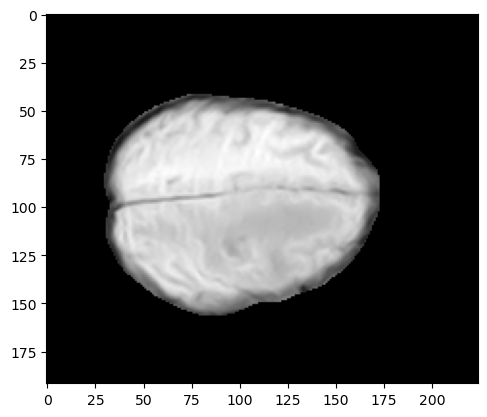

true_img shape: (192, 224)


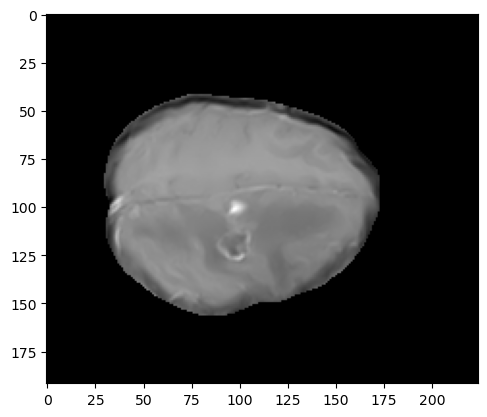

true_img shape: (192, 224)


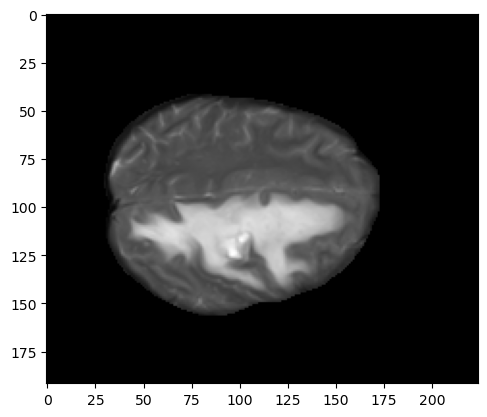

BraTS-SSA-00012-000-stk.npy
[[ 88. 114. 120. 138.]]
label.shape (3, 192, 224, 160), 96


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB dat

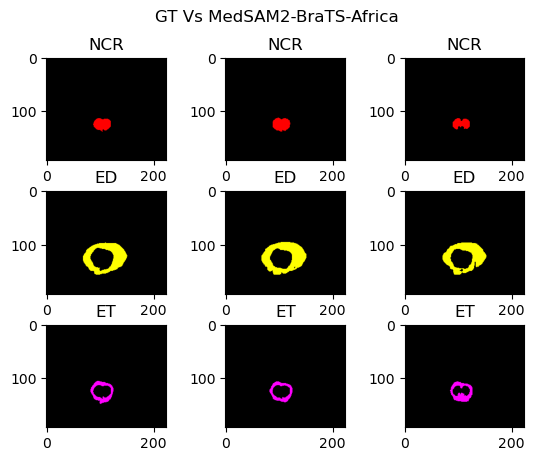

true_img shape: (192, 224)


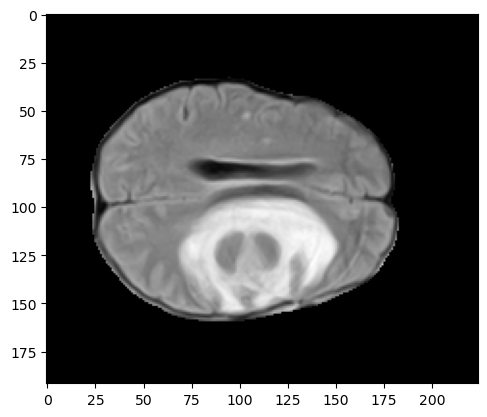

true_img shape: (192, 224)


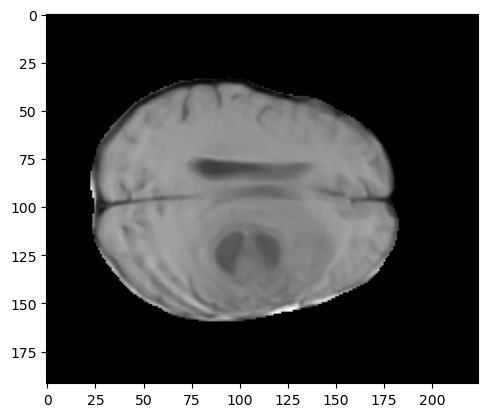

true_img shape: (192, 224)


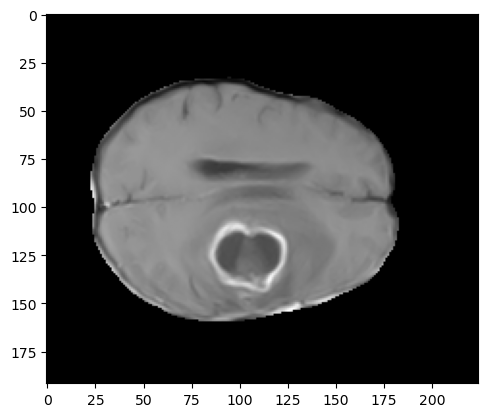

true_img shape: (192, 224)


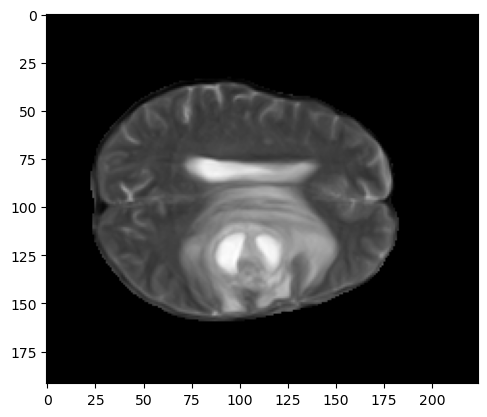

BraTS-SSA-00223-000-stk.npy
[[ 84.  63. 104.  95.]]
label.shape (3, 192, 224, 160), 71


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB dat

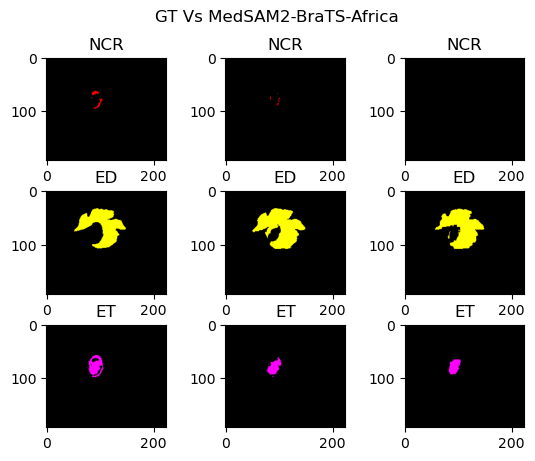

true_img shape: (192, 224)


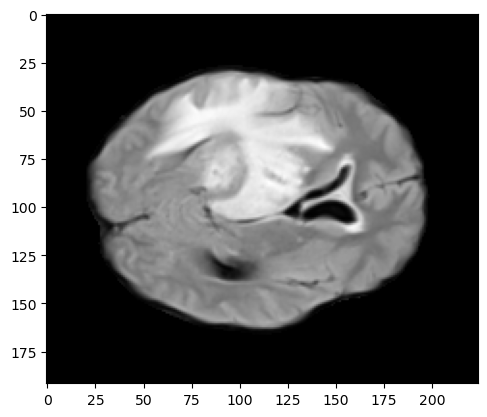

true_img shape: (192, 224)


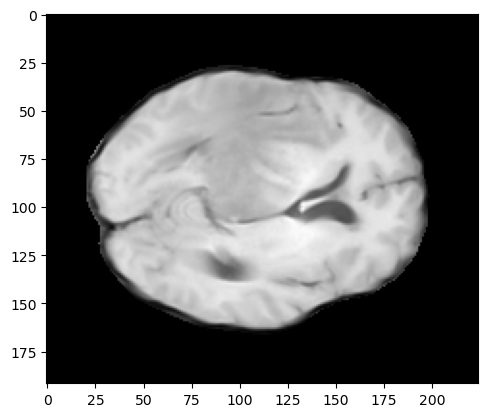

true_img shape: (192, 224)


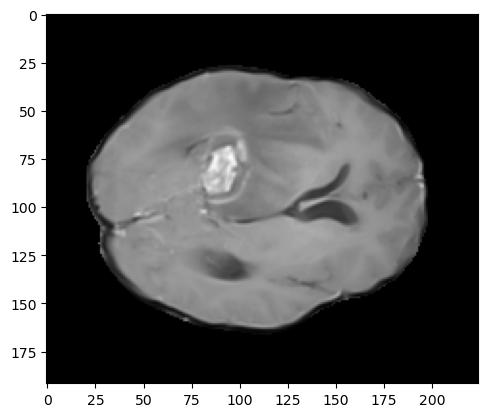

true_img shape: (192, 224)


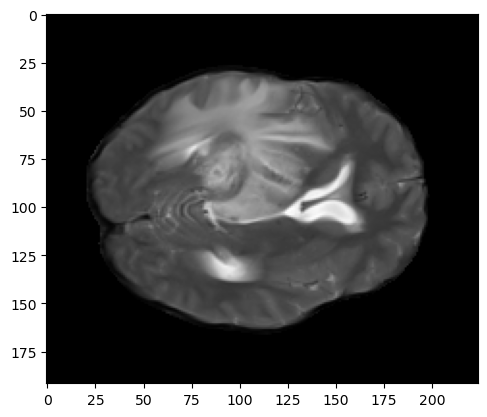

In [30]:

GLI_best_list = na_ssa_df[max_id == 'dice_ED'].name.to_list()
GLI_best_list
GLI_video_path = "/scratch_net/ken/radjoe/BraTS_SSA/Test/images_UNN"
GLI_label_path  = "/scratch_net/ken/radjoe/BraTS_SSA/Test/labels_UNN"
GLI_best_dataset = MRIDataset(GLI_video_path, GLI_label_path, GLI_best_list)
pred1 = '/scratch/radjoe/Projects/Experiments/SAMEXP/results/TT_NA_SSA/boxes/'
pred2 = '/scratch/radjoe/Projects/Experiments/SAMEXP/logs/tta_feature_ent_no_eted_no_rad_no_focal_eq/logs/BraTS_GLI'
visualize(GLI_best_dataset,pred1,'GT Vs MedSAM2-BraTS-Africa', GLI_video_path, pred2)

## NCR

In [17]:
a_ssa_df[max_id == 'dice_NCR']

,name,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET,recall_NCR,recall_ED,recall_ET,precision_NCR,precision_ED,precision_ET
2,BraTS-SSA-00049-000.npy,0.850239,0.802588,0.846821,2.828427,48.769348,58.403767,0.787952,0.842691,0.827064,0.923219,0.766128,0.867544
3,BraTS-SSA-00096-000.npy,0.733146,0.345016,0.742987,20.571823,41.243183,10.630146,0.730546,0.243778,0.726868,0.735765,0.590061,0.759838
4,BraTS-SSA-00113-000.npy,0.754802,0.776796,0.611024,47.520000,50.575169,16.982157,0.767884,0.783401,0.491701,0.742158,0.770302,0.806818
5,BraTS-SSA-00115-000.npy,0.616795,0.293922,0.465482,8.246211,44.944408,17.501390,0.739748,0.477532,0.335355,0.528889,0.212295,0.760629


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB dat

BraTS-SSA-00096-000-stk.npy
[[ 77.  39. 130. 110.]]
label.shape (3, 192, 224, 160), 65


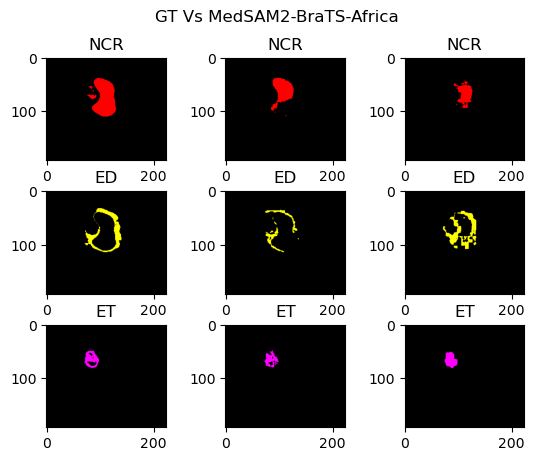

true_img shape: (192, 224)


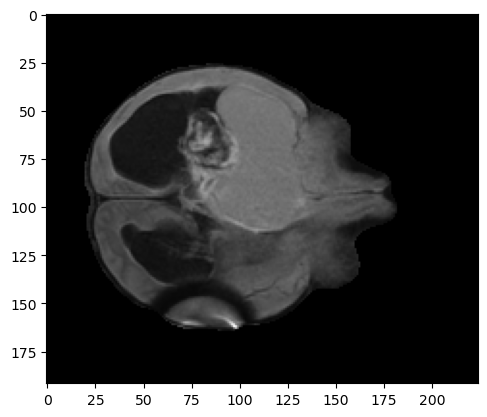

true_img shape: (192, 224)


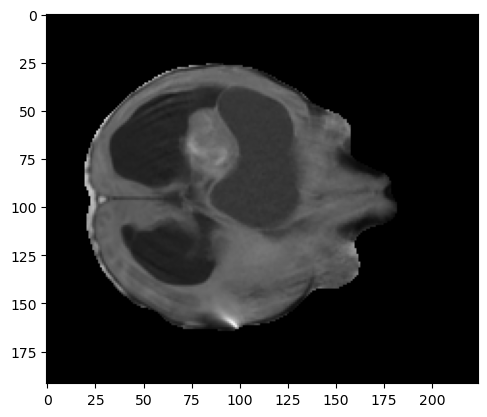

true_img shape: (192, 224)


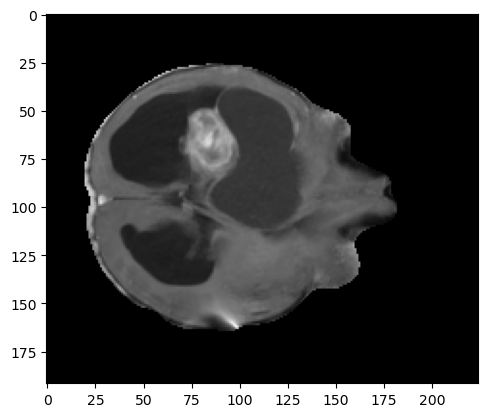

true_img shape: (192, 224)


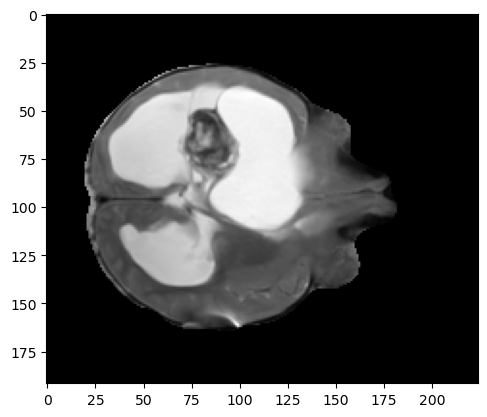

BraTS-SSA-00113-000-stk.npy
[[ 74. 100. 125. 159.]]
label.shape (3, 192, 224, 160), 91


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB dat

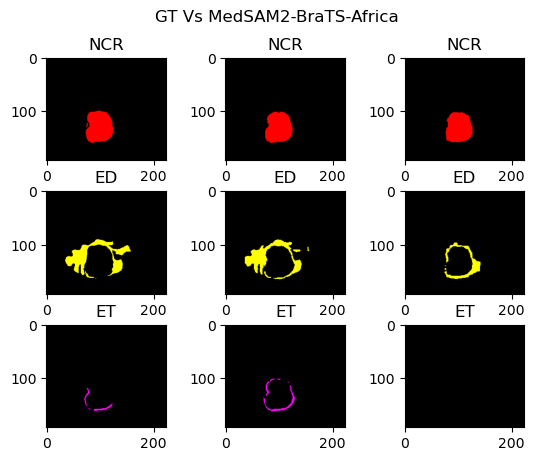

true_img shape: (192, 224)


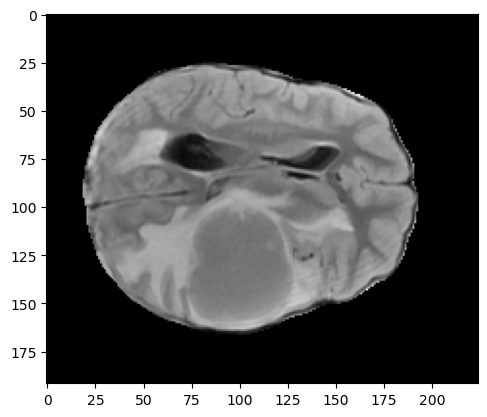

true_img shape: (192, 224)


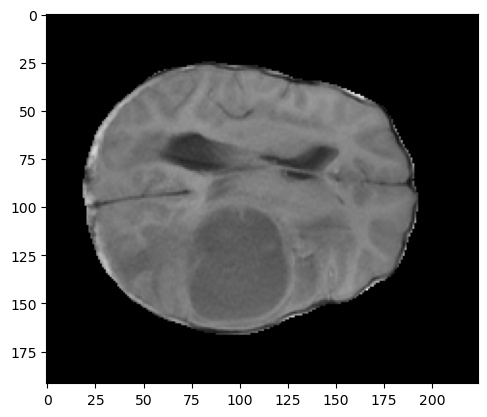

true_img shape: (192, 224)


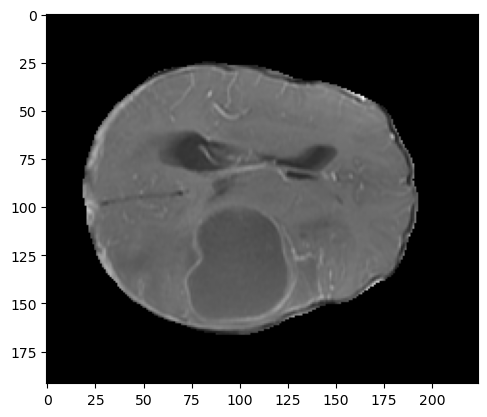

true_img shape: (192, 224)


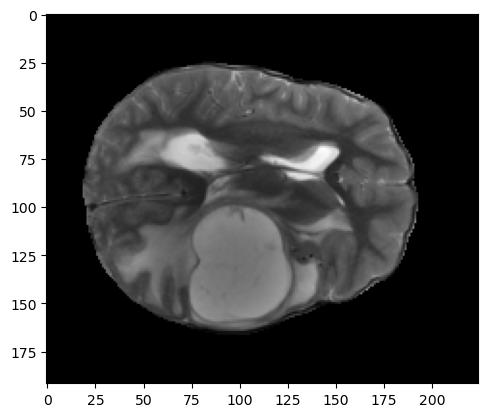

BraTS-SSA-00115-000-stk.npy
[[105.  41. 163. 122.]]
label.shape (3, 192, 224, 160), 96


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB dat

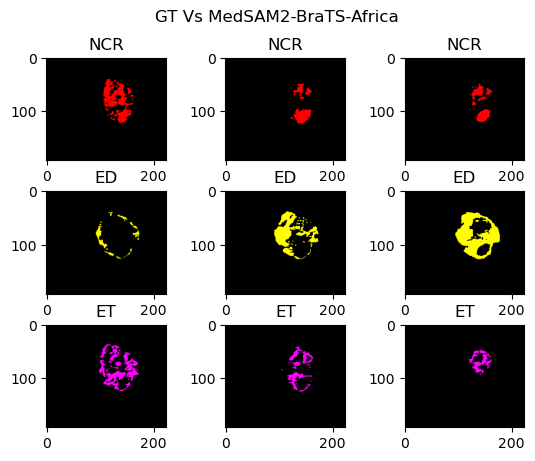

true_img shape: (192, 224)


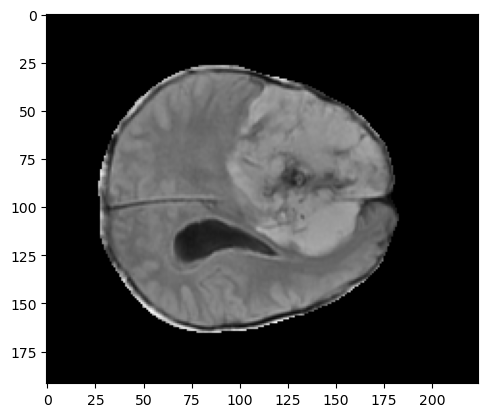

true_img shape: (192, 224)


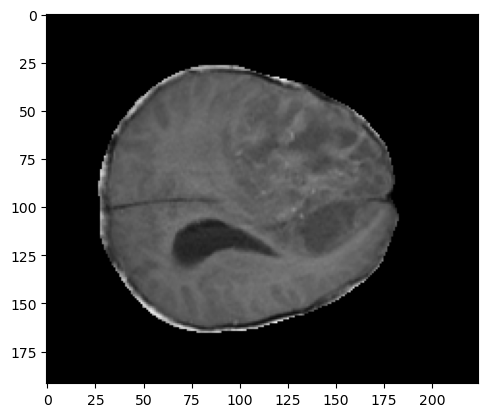

true_img shape: (192, 224)


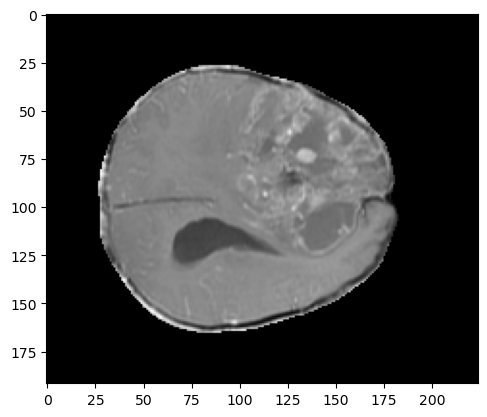

true_img shape: (192, 224)


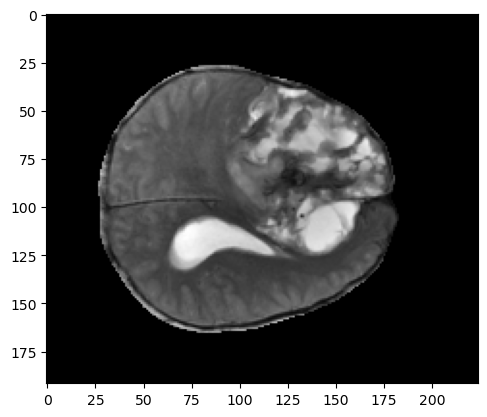

In [31]:
GLI_best_list = na_ssa_df[max_id == 'dice_NCR'].tail(3).name.to_list()
GLI_best_list
GLI_video_path = "/scratch_net/ken/radjoe/BraTS_SSA/Test/images_UNN"
GLI_label_path  = "/scratch_net/ken/radjoe/BraTS_SSA/Test/labels_UNN"
GLI_best_dataset = MRIDataset(GLI_video_path, GLI_label_path, GLI_best_list)
pred1 = '/scratch/radjoe/Projects/Experiments/SAMEXP/results/TT_NA_SSA/boxes/'
pred2 = '/scratch/radjoe/Projects/Experiments/SAMEXP/logs/tta_feature_ent_no_eted_no_rad_no_focal/logs/BraTS_GLI'
visualize(GLI_best_dataset,pred1,'GT Vs MedSAM2-BraTS-Africa', GLI_video_path, pred2)

## ET

In [19]:
na_ssa_df[max_id == 'dice_ET']

,name,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET,recall_NCR,recall_ED,recall_ET,precision_NCR,precision_ED,precision_ET
6,BraTS-SSA-00119-000.npy,0.332665,0.636030,0.675059,45.822964,64.292679,48.533493,0.384259,0.599577,0.663842,0.293286,0.677202,0.686662
7,BraTS-SSA-00152-000.npy,0.769118,0.725482,0.885938,5.385165,43.692104,8.602325,0.698904,0.821422,0.880933,0.855014,0.649610,0.891000


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].


BraTS-SSA-00119-000-stk.npy
[[124. 106. 129. 111.]]
label.shape (3, 192, 224, 160), 90


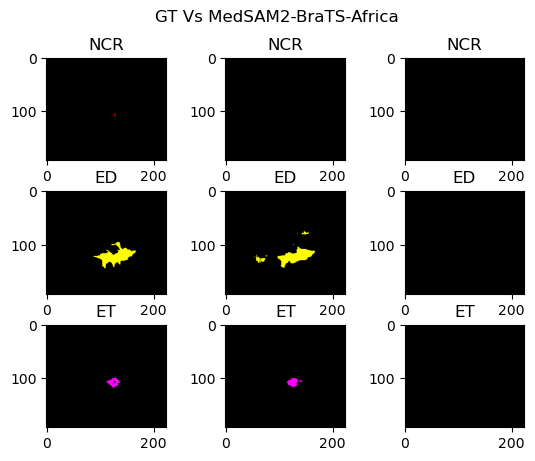

true_img shape: (192, 224)


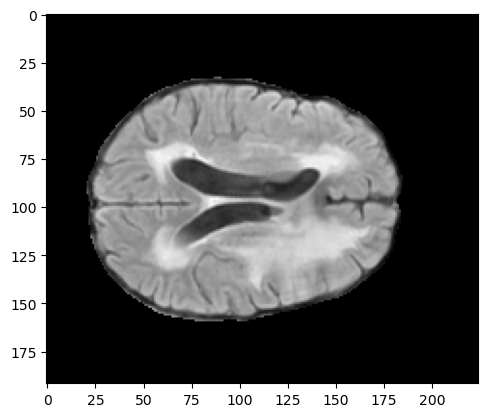

true_img shape: (192, 224)


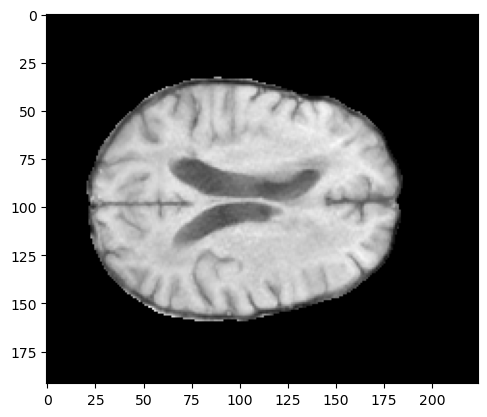

true_img shape: (192, 224)


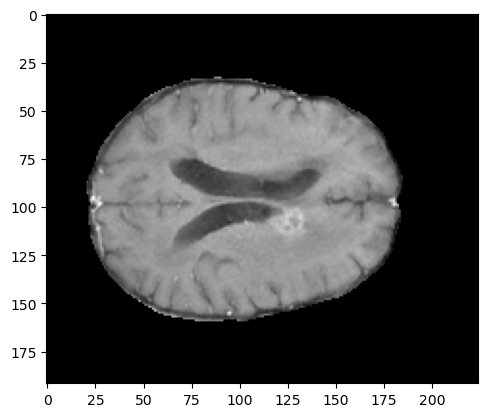

true_img shape: (192, 224)


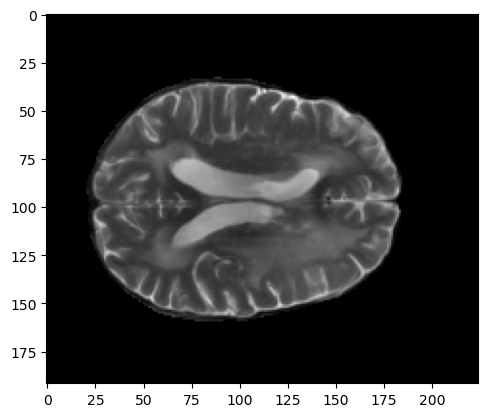

BraTS-SSA-00152-000-stk.npy
[[ 81.  95. 147. 145.]]
label.shape (3, 192, 224, 160), 108


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..128.0].
Clipping input data to the valid range for imshow with RGB dat

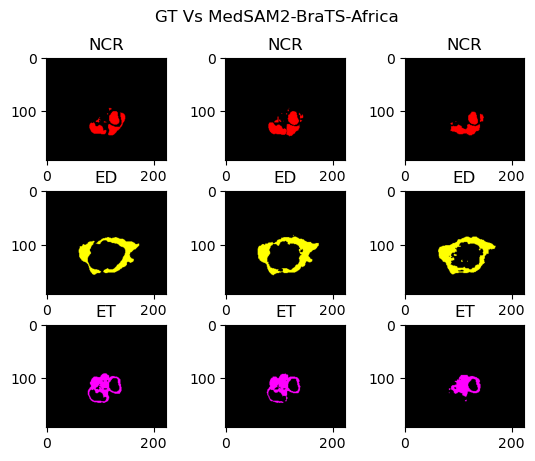

true_img shape: (192, 224)


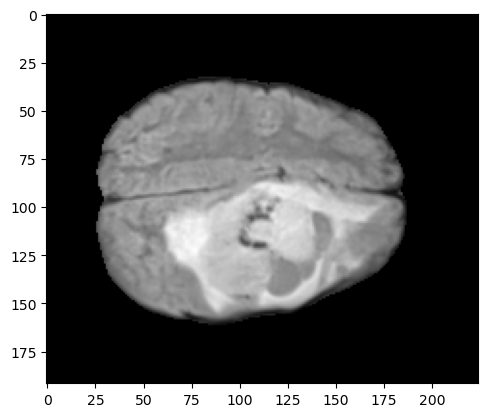

true_img shape: (192, 224)


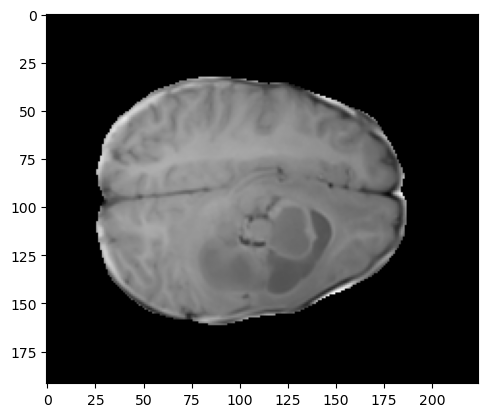

true_img shape: (192, 224)


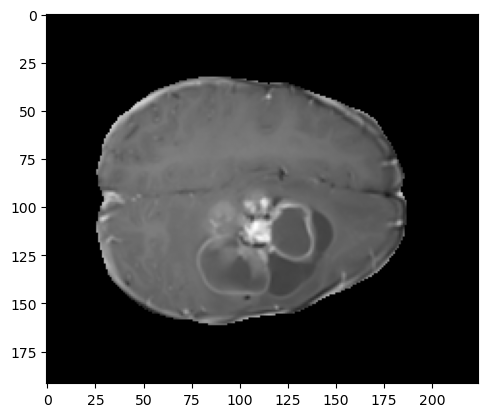

true_img shape: (192, 224)


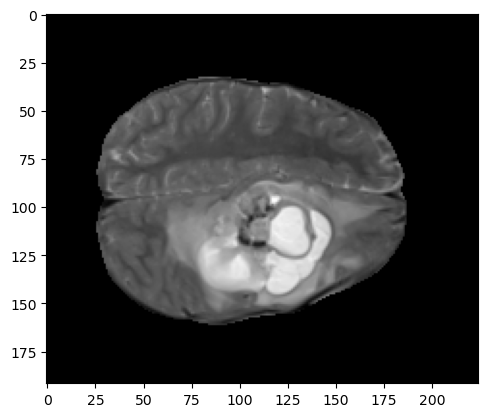

In [32]:
GLI_best_list = na_ssa_df[max_id == 'dice_ET'].name.to_list()
GLI_best_list
GLI_video_path = "/scratch_net/ken/radjoe/BraTS_SSA/Test/images_UNN"
GLI_label_path  = "/scratch_net/ken/radjoe/BraTS_SSA/Test/labels_UNN"
GLI_best_dataset = MRIDataset(GLI_video_path, GLI_label_path, GLI_best_list)
pred1 = '/scratch/radjoe/Projects/Experiments/SAMEXP/results/TT_NA_SSA/boxes/'
pred2 = '/scratch/radjoe/Projects/Experiments/SAMEXP/logs/tta_feature_ent_no_eted_no_rad_no_focal_eq/logs/BraTS_GLI'
visualize(GLI_best_dataset,pred1,'GT Vs MedSAM2-BraTS-Africa', GLI_video_path, pred2)

## This